# Data visualization and analysis

**Contexte:**
Ce travail consiste à développer un modèle de prédiction du coût final des sinistres d’assurance accidents du travail à partir d’un jeu de données synthétique réaliste de 90 000 réclamations.

**Objectif du notebook:**
Ce notebook a pour objectif d'explorer le dataset des réclamations d'accidents du travail afin de comprendre la structure des données, identifier les valeurs manquantes et anomalies et mieux comprendre la répartition et corrélation entre les variables. L'explication des données sera fait de manière progressive au fur et à mesure de l'avancement dans le notebook

---

## 0. Imports
---

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 1. Chargement des données
---

Trois datasets sont fournis:

- Un dataset pour l'entrainement du modèle **(train.csv)**

- Un autre dataset pour tester notre modèle **(test.csv)**

- Un dernier qui sert d'exemple d'output attendu **(sample_submission.csv)**

In [2]:
df_sample_submission = pd.read_csv("../data/sample_submission.csv")
df_train = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")

Regardons le début de chacun des trois datasets

## 2. Visualisation brève des datasets
---

***Train***

In [3]:
df_train.head()

,ClaimNumber,DateTimeOfAccident,DateReported,Age,Gender,MaritalStatus,DependentChildren,DependentsOther,WeeklyWages,PartTimeFullTime,HoursWorkedPerWeek,DaysWorkedPerWeek,ClaimDescription,InitialIncurredCalimsCost,UltimateIncurredClaimCost
0,WC8285054,2002-04-09T07:00:00Z,2002-07-05T00:00:00Z,48,M,M,0,0,500.00,F,38.0,5,LIFTING TYRE INJURY TO RIGHT ARM AND WRIST INJURY,1500,4748.203388
1,WC6982224,1999-01-07T11:00:00Z,1999-01-20T00:00:00Z,43,F,M,0,0,509.34,F,37.5,5,STEPPED AROUND CRATES AND TRUCK TRAY FRACTURE ...,5500,6326.285819
2,WC5481426,1996-03-25T00:00:00Z,1996-04-14T00:00:00Z,30,M,U,0,0,709.10,F,38.0,5,CUT ON SHARP EDGE CUT LEFT THUMB,1700,2293.949087
3,WC9775968,2005-06-22T13:00:00Z,2005-07-22T00:00:00Z,41,M,S,0,0,555.46,F,38.0,5,DIGGING LOWER BACK LOWER BACK STRAIN,15000,17786.487170
4,WC2634037,1990-08-29T08:00:00Z,1990-09-27T00:00:00Z,36,M,M,0,0,377.10,F,38.0,5,REACHING ABOVE SHOULDER LEVEL ACUTE MUSCLE STR...,2800,4014.002925


Comme attendu, le dataset train contient une liste d'accidents, avec pour chaque accident différents facteurs. On retrouve bien les paramètres évoqués sur la page Kaggle qui sont les suivants:

***ClaimNumber***: Identifiant unique de la réclamation

***DateTimeOfAccident***: Date et heure de l’accident

***DateReported***: Date à laquelle l’accident a été déclaré

***Age***: Âge du travailleur

***Gender***: Genre du travailleur

***MaritalStatus***: Statut marital du travailleur (Married, Single or Unknown).

***DependentChildren***: Nombre d’enfants à charge

***DependentsOther***: Nombre d’autres personnes à charge (hors enfants)

***WeeklyWages***: Salaire hebdomadaire total

***PartTimeFullTime***: Type de contrat (P: temps partiel, F: temps plein)

***HoursWorkedPerWeek***: Nombre total d’heures travaillées par semaine

***DaysWorkedPerWeek***: Nombre de jours travaillés par semaine

***ClaimDescription***: Description textuelle libre de l’accident

***InitialIncurredClaimCost***: Estimation initiale du coût du sinistre par l’assureur

***UltimateIncurredClaimCost***: Coût total final du sinistre payé par la compagnie d’assurance. -> Target

***Test***

In [4]:
df_test.head()

,ClaimNumber,DateTimeOfAccident,DateReported,Age,Gender,MaritalStatus,DependentChildren,DependentsOther,WeeklyWages,PartTimeFullTime,HoursWorkedPerWeek,DaysWorkedPerWeek,ClaimDescription,InitialIncurredCalimsCost
0,WC8145235,2002-04-02T10:00:00Z,2002-05-07T00:00:00Z,26,M,S,1,0,600.18,F,40.0,5,CAUGHT RIGHT HAND WITH HAMMER BURN TO RIGHT HAND,5300
1,WC2005111,1988-04-06T16:00:00Z,1988-04-15T00:00:00Z,31,M,M,0,0,311.54,F,35.0,5,SPRAINED RIGHT ANKLE FRACTURE RIGHT ELBOW,2000
2,WC6899143,1999-03-08T09:00:00Z,1999-04-04T00:00:00Z,57,M,M,0,0,1000.00,F,38.0,5,STRUCK HAMMER CRUSH INJURY FINGERS HAND,20000
3,WC5502023,1996-07-26T09:00:00Z,1996-09-04T00:00:00Z,33,M,M,0,0,200.00,F,38.0,5,STRUCK AGAINST AIR HOSE STRUCK GLASS LACERATIO...,350
4,WC4785156,1994-04-13T14:00:00Z,1994-07-07T00:00:00Z,32,F,M,0,0,359.60,F,40.0,5,FOREIGN BODY IN RIGHT FOOT BRUISED RIGHT BIG TOE,3000


Comme attendu également, le dataset "test" contient les mêmes colonnes, à l'exception de la target **UltimateIncurredClaimCost**

Regardons juste les tailles des deux datasets pour être sûr qu'il y a bien une (et uniquement une) colonne en moins dans le dataset de test

In [5]:
print("df_train.shape:", df_train.shape)
print("df_test.shape:", df_test.shape)

df_train.shape: (54000, 15)
df_test.shape: (36000, 14)


Tout semble correct, passons maintenant au format de l'échantillon à soumettre.

***Sample submission***

In [6]:
df_sample_submission.head()

,ClaimNumber,UltimateIncurredClaimCost
0,WC8145235,3226.599525
1,WC2005111,427.887042
2,WC6899143,548.294914
3,WC5502023,992.002064
4,WC4785156,18069.460460


Le rendu final est un tableau d'uniquement deux colonnes: le numéro de la réclamation (**ClaimNumber**) et la target, c'est à dire le coût réel payé (**UltimateIncurredClaimCost**)

## 3. Data analysis
---

### 3.1 Valeurs NaN et types

Regardons les valeurs manquantes et les types de valeurs pour chaque colonnes

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54000 entries, 0 to 53999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ClaimNumber                54000 non-null  object 
 1   DateTimeOfAccident         54000 non-null  object 
 2   DateReported               54000 non-null  object 
 3   Age                        54000 non-null  int64  
 4   Gender                     54000 non-null  object 
 5   MaritalStatus              53971 non-null  object 
 6   DependentChildren          54000 non-null  int64  
 7   DependentsOther            54000 non-null  int64  
 8   WeeklyWages                54000 non-null  float64
 9   PartTimeFullTime           54000 non-null  object 
 10  HoursWorkedPerWeek         54000 non-null  float64
 11  DaysWorkedPerWeek          54000 non-null  int64  
 12  ClaimDescription           54000 non-null  object 
 13  InitialIncurredCalimsCost  54000 non-null  int

In [8]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ClaimNumber                36000 non-null  object 
 1   DateTimeOfAccident         36000 non-null  object 
 2   DateReported               36000 non-null  object 
 3   Age                        36000 non-null  int64  
 4   Gender                     36000 non-null  object 
 5   MaritalStatus              35982 non-null  object 
 6   DependentChildren          36000 non-null  int64  
 7   DependentsOther            36000 non-null  int64  
 8   WeeklyWages                36000 non-null  float64
 9   PartTimeFullTime           36000 non-null  object 
 10  HoursWorkedPerWeek         36000 non-null  float64
 11  DaysWorkedPerWeek          36000 non-null  int64  
 12  ClaimDescription           36000 non-null  object 
 13  InitialIncurredCalimsCost  36000 non-null  int

Dans le notebook ***2.Data cleaning***, nous ferons les modifications suivantes:

- Les valeurs *NaN* sont uniquements présentes dans le statut marital, lors du processing des données, nous allons les remplacer par *Unknown* (il y en a peu)

- Les dates seront converties au format *"datetime"*

### 3.2 Duplicats

Vérification des duplicats:

In [9]:
df_train.duplicated().sum()

0

In [10]:
df_test.duplicated().sum()

0

In [11]:
df_train["ClaimNumber"].duplicated().sum()
df_test["ClaimNumber"].duplicated().sum()

0

**Pas de duplicats**

### 3.3 Valeurs uniques

In [12]:
for col in df_train.columns:
    
    print(f"\n*{col}*")

    print("Nombre de valeurs uniques :", df_train[col].nunique())
    
    print(df_train[col].unique())


*ClaimNumber*
Nombre de valeurs uniques : 54000
['WC8285054' 'WC6982224' 'WC5481426' ... 'WC3609528' 'WC5038565'
 'WC2542601']

*DateTimeOfAccident*
Nombre de valeurs uniques : 36673
['2002-04-09T07:00:00Z' '1999-01-07T11:00:00Z' '1996-03-25T00:00:00Z' ...
 '1993-04-10T09:00:00Z' '2004-08-21T18:00:00Z' '2002-04-28T09:00:00Z']

*DateReported*
Nombre de valeurs uniques : 6653
['2002-07-05T00:00:00Z' '1999-01-20T00:00:00Z' '1996-04-14T00:00:00Z' ...
 '1988-01-29T00:00:00Z' '2002-03-27T00:00:00Z' '2002-12-11T00:00:00Z']

*Age*
Nombre de valeurs uniques : 68
[48 43 30 41 36 50 39 56 49 20 22 29 25 17 58 52 27 34 33 23 42 53 37 19
 47 51 28 16 18 38 24 21 32 44 61 54 45 26 57 46 62 31 55 35 40 63 65 59
 15 60 64 74 68 66 69 14 70 72 67 71 13 75 79 73 76 80 78 81]

*Gender*
Nombre de valeurs uniques : 3
['M' 'F' 'U']

*MaritalStatus*
Nombre de valeurs uniques : 3
['M' 'U' 'S' nan]

*DependentChildren*
Nombre de valeurs uniques : 9
[0 3 1 2 5 9 4 6 8]

*DependentsOther*
Nombre de valeurs uniq

Il semble que plusieurs accidents au eu lieu au même moment (plausible) et environ la moitié des descriptions des réclamations sont des doublons (plausible également).

### 3.4 Valeurs numériques

Regardons les valeurs numériques d’un peu plus près

In [13]:
df_train.describe()

,Age,DependentChildren,DependentsOther,WeeklyWages,HoursWorkedPerWeek,DaysWorkedPerWeek,InitialIncurredCalimsCost,UltimateIncurredClaimCost
count,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,5.400000e+04,5.400000e+04
mean,33.842370,0.119185,0.009944,416.364807,37.735084,4.905759,7.841146e+03,1.100337e+04
std,12.122165,0.517780,0.109348,248.638669,12.568704,0.552129,2.058408e+04,3.339099e+04
min,13.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000e+00,1.218868e+02
25%,23.000000,0.000000,0.000000,200.000000,38.000000,5.000000,7.000000e+02,9.263384e+02
50%,32.000000,0.000000,0.000000,392.200000,38.000000,5.000000,2.000000e+03,3.371242e+03
75%,43.000000,0.000000,0.000000,500.000000,40.000000,5.000000,9.500000e+03,8.197249e+03
max,81.000000,9.000000,5.000000,7497.000000,640.000000,7.000000,2.000000e+06,4.027136e+06


In [14]:
df_test.describe()

,Age,DependentChildren,DependentsOther,WeeklyWages,HoursWorkedPerWeek,DaysWorkedPerWeek,InitialIncurredCalimsCost
count,36000.000000,36000.000000,36000.000000,36000.00000,36000.000000,36000.000000,36000.000000
mean,33.856556,0.120000,0.009611,416.37745,37.758841,4.912417,7679.306889
std,12.124416,0.522437,0.108357,242.49109,11.951296,0.540451,17501.991600
min,13.000000,0.000000,0.000000,1.00000,0.000000,1.000000,1.000000
25%,23.000000,0.000000,0.000000,200.00000,38.000000,5.000000,650.000000
50%,32.000000,0.000000,0.000000,395.18500,38.000000,5.000000,2000.000000
75%,43.000000,0.000000,0.000000,500.00000,40.000000,5.000000,9500.000000
max,80.000000,8.000000,5.000000,7400.00000,700.000000,7.000000,725000.000000


Les distributions statistiques des datasets train et test semblent cohérentes.

Plusieurs outliers dans une grande majorité des colonnes.

Certaines colonnes contiennent des anomalies:
- 7400 pour un salaire hebdomadaire, cela peut être un problème de devise, de compréhension de la question ou d'unités (ou une valeur réelle).
- 640 et 700 heures travaillées par semaine ne sont pas possibles

### 3.4.1 Vérification des anomalies

#### Vérification du nombre de lignes avec un travail de plus de 168h par semaine

In [15]:
(df_train["HoursWorkedPerWeek"] > 168).sum()

36

#### Vérification du nombre de lignes avec plus de 24h de travail par jour

In [16]:
hours_per_day = (
    df_train["HoursWorkedPerWeek"] /
    df_train["DaysWorkedPerWeek"]
)

len(df_train[hours_per_day > 24])

54

#### Vérification du nombre de lignes où la date du rapport est antérieure à celle de l'accident

In [17]:
date_accident = pd.to_datetime(df_train["DateTimeOfAccident"])
date_reported = pd.to_datetime(df_train["DateReported"])

(date_reported < date_accident).sum()

5

**Toutes ces incohérences seront traitées dans le notebook "data cleaning"**

### 3.4.2 Analyse des réclamations

In [18]:
df_train["ClaimDescription"].str.len().describe()

count    54000.000000
mean        43.453704
std         10.217058
min          3.000000
25%         37.000000
50%         43.000000
75%         50.000000
max         94.000000
Name: ClaimDescription, dtype: float64

In [19]:
(df_train["ClaimDescription"].str.strip() == "").sum()

0

In [20]:
df_train["ClaimDescription"].sample(20, random_state=42)

30246    RACK OF TIMBER FELL ON ARM BRUISED LEFT KNEE A...
34164              ROSS RIVER VIRUS INFECTION RASH TO ARMS
40692    SLIPPED WHILST HANDLING KNIFE LACERATION LEFT ...
28724    STRUCK METAL SPINNING DRILL LACERATED LEFT LOW...
28097    TIMBER FELL ON LEFT WRIST SPRAIN HEAD SOFT TIS...
31492                           REPETITIVE USE STRAIN BACK
7950     HEAVY LIFTING AND TWISTING MUSCLE STRAIN TO BA...
40973    FALLING CRATES SOFT TISSUE INJURY RIGHT SHOULD...
4448     FELL OFF LADDER STRAINED RIGHT SHOULDER UPPER ARM
26354                  HANDLING TIMBER SPLINTER RIGHT HAND
49597              REPETITIVE LOWER BACK LOWER BACK STRAIN
36567           CRUSHED FINGER FRACTURE LEFT LITTLE FINGER
45083        REDBACK SPIDER BITE RIGHT FOOT RIGHT FRACTURE
46613    SLIPPED CUTTING THUMB LACERATION LEFT MIDDLE F...
51967          JAMMED THUMB IN GRINDER LEFT HAND LEFT HAND
2960                             GRINDING FOREIGN BODY EYE
25326           TWISTED WHILST DRILLING STRAIN RIGHT ELB

In [21]:
desc_len = df_train["ClaimDescription"].str.len()

df_train.loc[
    desc_len.sort_values().index,
    ["ClaimDescription"]
].head(40)

,ClaimDescription
16263,EYE
21042,EYE
40914,EYE
45516,EYE
39136,EYE
4806,BACK
48245,BACK
3987,BACK
8236,BACK
24644,NECK


Est-ce que des réclamations avec uniquement comme contexte "Eye" et "back" sont suffisants ? On se doute qu'il s'agit de la partie impactée mais cela nous donne assez peu de contexte

## 4. Data visualization
---

### 4.1 Histogrammes par variables

#### 4.1.1 Genre

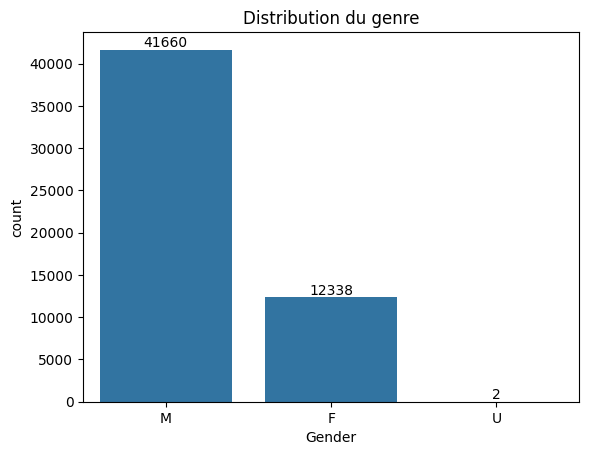

In [22]:
ax = sns.countplot(data=df_train, x="Gender")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Distribution du genre")
plt.show()

#### 4.1.2 Statut marital

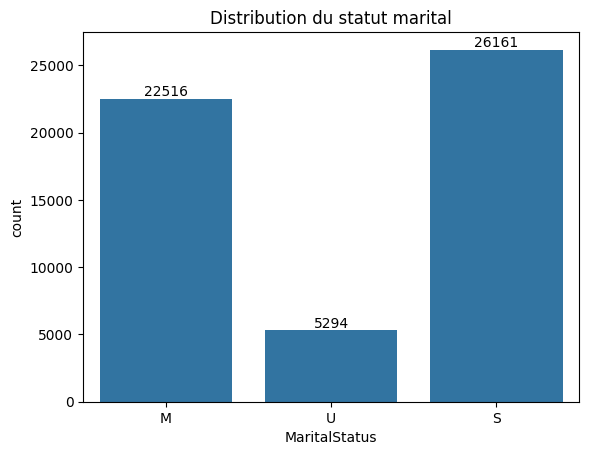

In [23]:
ax = sns.countplot(data=df_train, x="MaritalStatus")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Distribution du statut marital")
plt.show()

#### 4.1.3 Temps plein/partiel

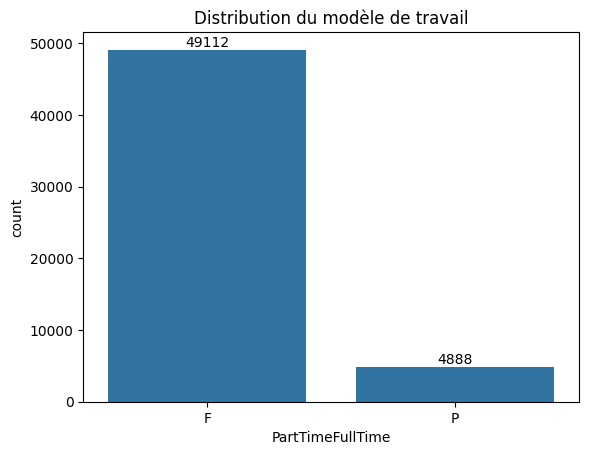

In [24]:
ax = sns.countplot(data=df_train, x="PartTimeFullTime")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Distribution du modèle de travail")
plt.show()

#### 4.1.4 Age

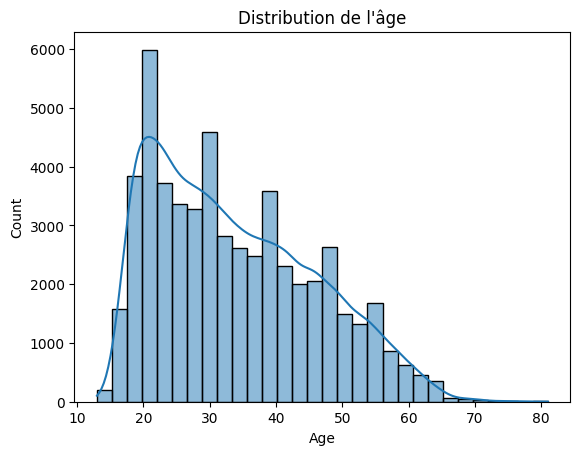

In [25]:
sns.histplot(df_train["Age"], bins=30, kde=True)
plt.title("Distribution de l'âge")
plt.show()

#### 4.1.4 Salaire hebdomadaire

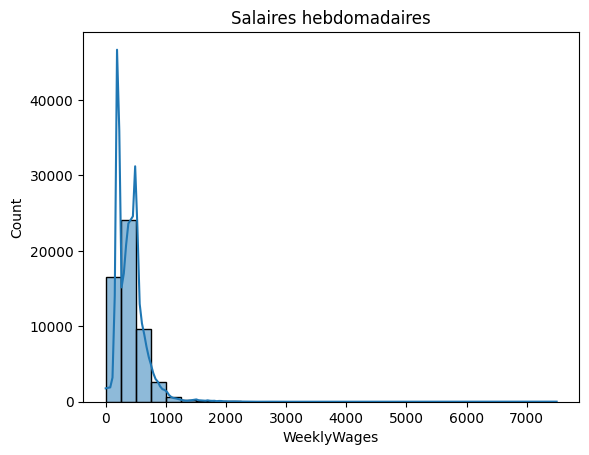

In [26]:
sns.histplot(df_train["WeeklyWages"], bins=30, kde=True)
plt.title("Salaires hebdomadaires")
plt.show()

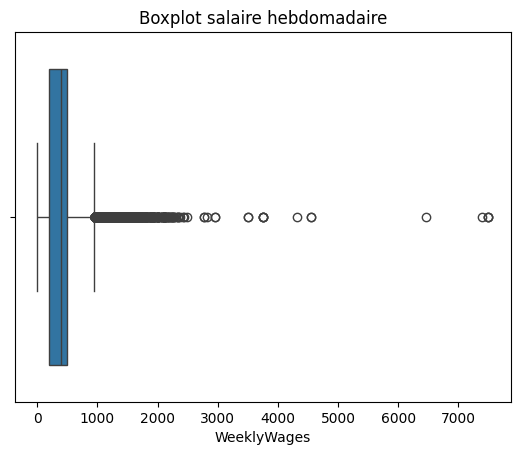

In [27]:
sns.boxplot(x=df_train["WeeklyWages"])
plt.title("Boxplot salaire hebdomadaire")
plt.show()

Quelques gros outliers au niveau du salaire hebdomadaires, mais nous allons les conserver.

#### 4.1.5 Heures travaillées

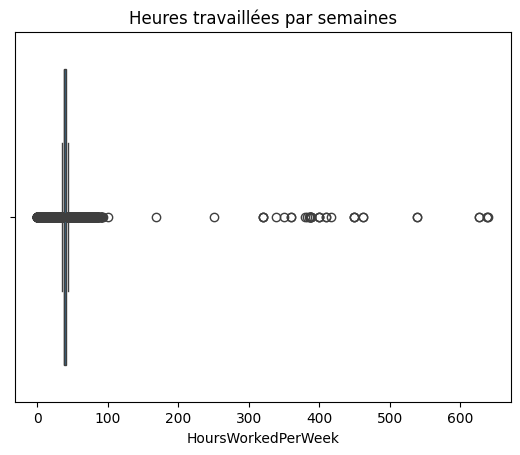

In [28]:
sns.boxplot(x=df_train["HoursWorkedPerWeek"])
plt.title("Heures travaillées par semaines")
plt.show()

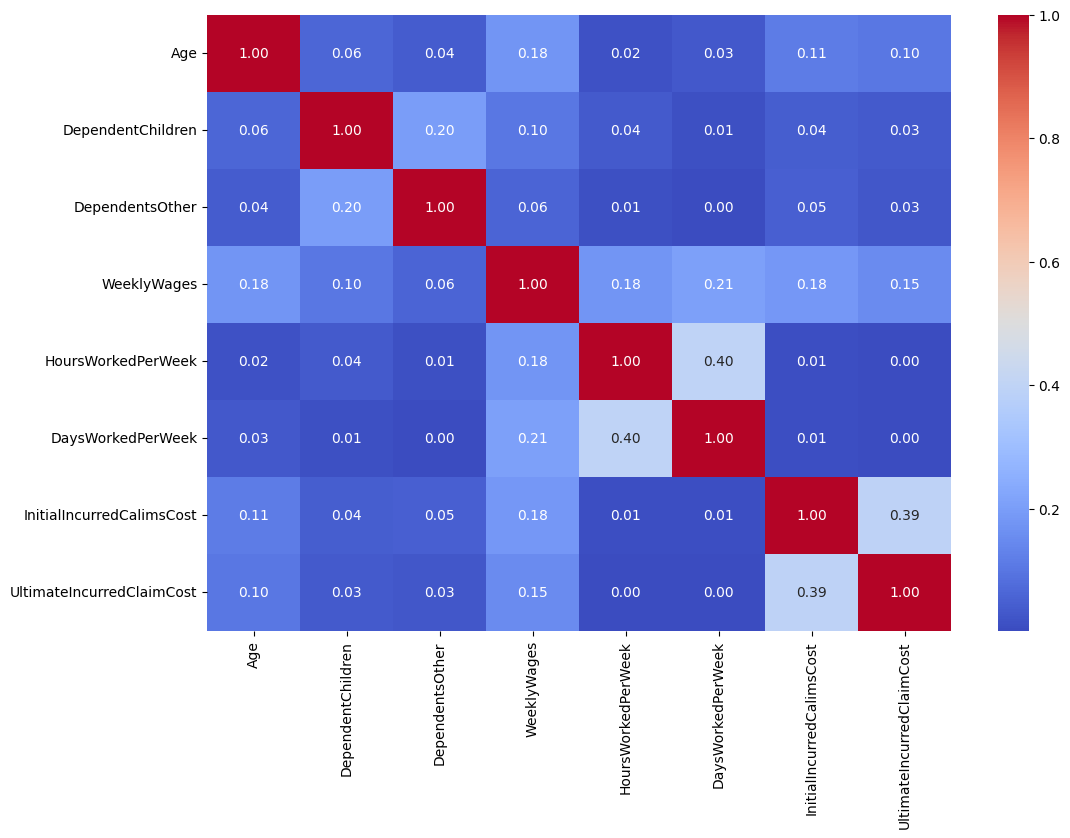

In [30]:
num_cols = df_train.select_dtypes(include=np.number)

corr = num_cols.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

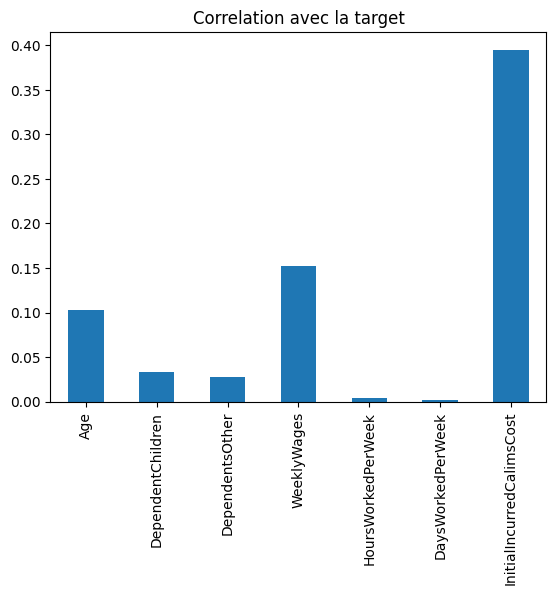

In [31]:
corr_target = corr["UltimateIncurredClaimCost"]

corr_target.drop("UltimateIncurredClaimCost").plot(
    kind="bar"
)

plt.title("Correlation avec la target")
plt.show()

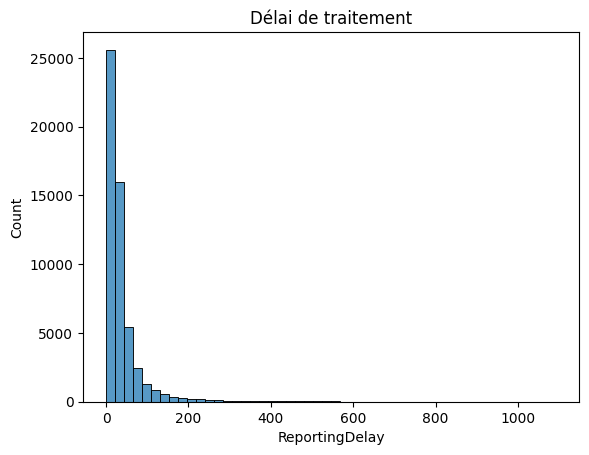

In [32]:
df_train["DateTimeOfAccident"] = pd.to_datetime(
    df_train["DateTimeOfAccident"]
)

df_train["DateReported"] = pd.to_datetime(
    df_train["DateReported"]
)

df_train["ReportingDelay"] = (
    df_train["DateReported"]
    - df_train["DateTimeOfAccident"]
).dt.days

sns.histplot(df_train["ReportingDelay"], bins=50)
plt.title("Délai de traitement")
plt.show()

La majorité des accidents sont traités dans un délai de moins de 6 mois

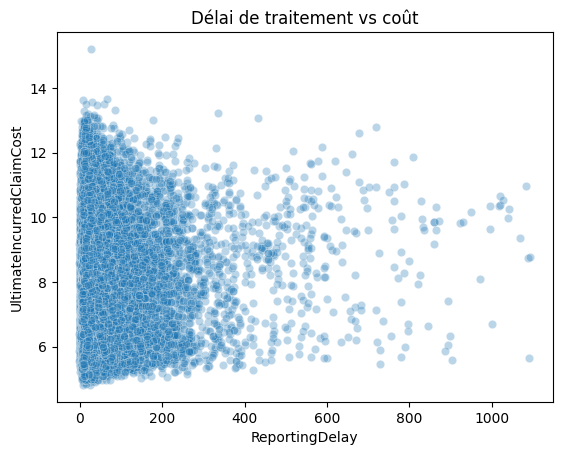

In [33]:
sns.scatterplot(
    x=df_train["ReportingDelay"],
    y=np.log1p(df_train["UltimateIncurredClaimCost"]),
    alpha=0.3
)

plt.title("Délai de traitement vs coût")
plt.show()

On pourrait penser que plus une réclamation est coûteuse plus elle va prendre du temps, mais cela n'est pas spécialement le cas

Afin de garder un travail assez condensé et pour respecter le temps imparti, le travail sur ce notebook est terminé, avec une bonne idée et réprésentation des anomalies ainsi qu'une bonne visualisation des variables et leurs corrélations. Néanmoins, si l'on veut aller un peu plus loin, voici quelques pistes intéressantes à explorer:
- Analyse temporelle (en fonction de la saison mais aussi du jour de la semaine, ou même de l'année)
- Analyse NLP plus poussée, avec par exemple une comparaison du vocabulaire vs coût de la réclamation